# IV.2.2 — Spatial Characteristic Analysis of BISINDO Skeleton Data

This notebook generates visualizations to document **spatial issues/characteristics** found in the BISINDO skeleton data before pre-processing.

Three analysis groups:
1. **IV.2.2.1 — Position and Scale Variations Across Signers** → Scatter overlay, keypoint distance boxplot, multi-signer skeleton overlay
2. **IV.2.2.2 — Inter-frame Coordinate Instability (Micro-shift)** → Coordinate fluctuation line chart, displacement histogram
3. **IV.2.2.3 — [0,0] Coordinate Noise** → Noise frequency heatmap per keypoint, noise bar chart per signer, frame visualization with noise

---

In [7]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
from collections import defaultdict
import os

# ── Paper-style global rcParams (consistent with reference notebooks) ─────────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.linewidth'     : 0.8,
    'axes.grid'          : False,
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'figure.titlesize'   : 11,
    'figure.titleweight' : 'bold',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
})

# ── Color palette ─────────────────────────────────────────────────────────────
C_LH     = '#2166AC'   # Left hand  – deep blue
C_RH     = '#D6604D'   # Right hand – muted red
C_EDGE   = '#555555'   # Skeleton edges
C_NOISE  = '#B2182B'   # Noise highlight – red
C_VALID  = '#4393C3'   # Valid keypoint
GRAYS    = ['#1a1a1a', '#555555', '#888888', '#bbbbbb']
BAR_EC   = 'black'
BAR_LW   = 0.6

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = '../data/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hand skeleton edges ───────────────────────────────────────────────────────
HAND_EDGES = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]
CONNECTIONS = [(u,v) for u,v in HAND_EDGES] + [(u+21,v+21) for u,v in HAND_EDGES]

IDX_LH   = np.arange(0, 21)    # Left hand
IDX_RH   = np.arange(21, 42)   # Right hand
IDX_HAND = np.arange(0, 42)    # Both hands

print('Configuration loaded.')

Configuration loaded.


## 0. Load Data

In [8]:
# ── CONFIGURATION — adjust path to your directory structure ─────────────
PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

video_ids = list(data.keys())
print(f'Total videos : {len(video_ids)}')
print(f'Sample IDs   : {video_ids[:5]}')

# Extract signer info from video ID (format: Pxx_Sxxx_Rxx)
speakers = sorted(set(v.split('_')[0] for v in video_ids))
print(f'Signers      : {speakers}')

# Keypoint layout (86 points):
# [0:21]  = Left Hand  (21 pts)
# [21:42] = Right Hand (21 pts)
# [42:61] = Mouth      (19 pts)
# [61:86] = Pose/Body  (25 pts)
K_TOTAL = 86

Total videos : 750
Sample IDs   : ['P01_S001_R01', 'P01_S001_R02', 'P01_S001_R03', 'P01_S001_R04', 'P01_S001_R05']
Signers      : ['P01', 'P02', 'P03', 'P04', 'P05']


---
## IV.2.2.1 — Position and Scale Variations Across Signers

Three visualizations:
- **Fig A** — Hand coordinate scatter plot overlay for all signers (raw, before normalization)
- **Fig B** — Wrist → middle finger tip distance boxplot per signer (hand scale variation)
- **Fig C** — Skeleton visualization overlay of several signers in a single frame

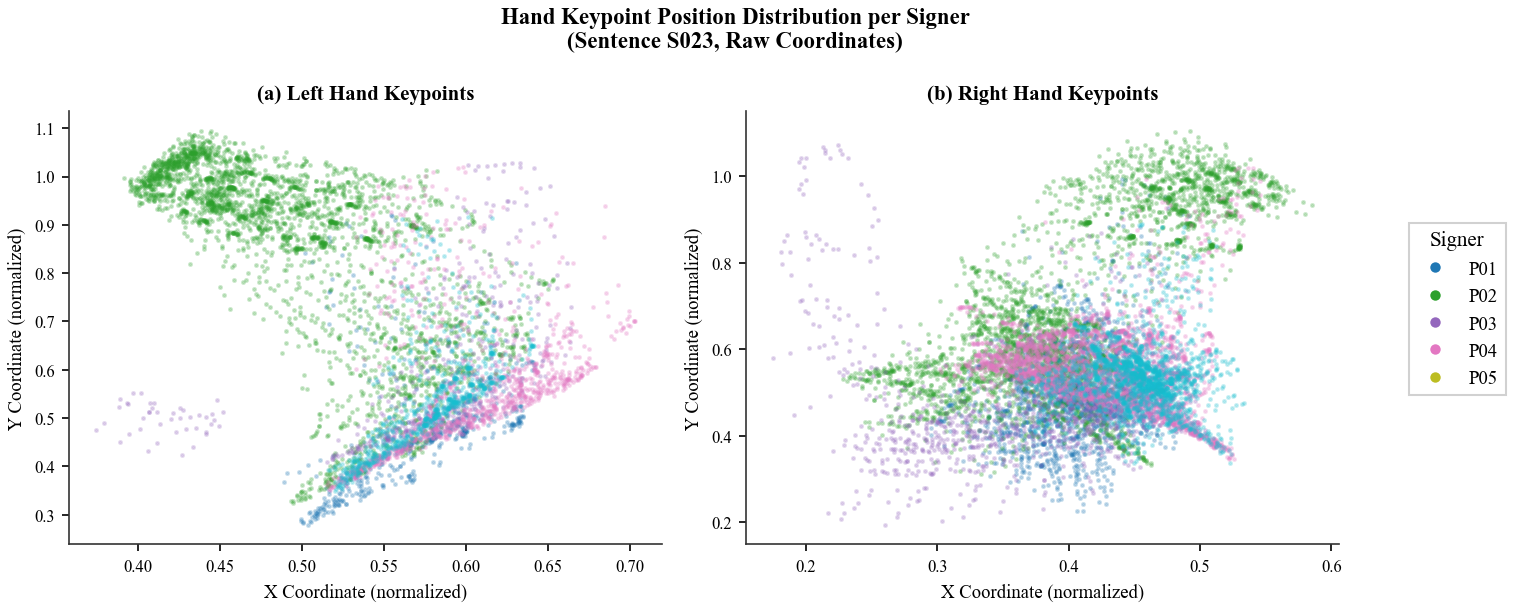

[SAVED] ../data/results\spatial_A_same_sentence_scatter.png


In [25]:
# ── Fig A: Hand Coordinate Scatter Overlay (Same Sentence Across Signers) ────
# Purpose:
# Show inter-signer spatial variation using the SAME sentence only.

# ── CONFIGURATION ─────────────────────────────────────────────────────────────

TARGET_SEQUENCE = 'S023'
TARGET_REP      = 'R01'

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=150)

titles = ['(a) Left Hand Keypoints', '(b) Right Hand Keypoints']
idx_parts = [IDX_LH, IDX_RH]

colors_sp = plt.cm.tab10(np.linspace(0, 0.9, len(speakers)))

# ──────────────────────────────────────────────────────────────────────────────

for ax, idx_part, title in zip(axes, idx_parts, titles):

    for sp, color in zip(speakers, colors_sp):

        # Same sentence + same repetition
        sp_vids = sorted([
            v for v in video_ids
            if v.startswith(sp)
            and TARGET_SEQUENCE in v
            and f'_{TARGET_REP}' in v
        ])

        if not sp_vids:
            continue

        # Use only one video per signer
        vid = sp_vids[0]

        kp = data[vid]['keypoints']   # (T, K, 2)

        pts = kp[:, idx_part, :]      # (T, 21, 2)

        # Remove [0,0]
        valid = ~(
            (pts[:,:,0] == 0) &
            (pts[:,:,1] == 0)
        )

        xs = pts[:,:,0][valid]
        ys = pts[:,:,1][valid]

        ax.scatter(
            xs,
            ys,
            s=2,
            alpha=0.22,
            color=color,
            label=sp,
            rasterized=True
        )

    # ── Axis Style ────────────────────────────────────────────────────────────

    ax.set_title(title)

    ax.set_xlabel('X Coordinate (normalized)')
    ax.set_ylabel('Y Coordinate (normalized)')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────

handles = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=plt.cm.tab10(i / len(speakers)),
        markersize=6,
        label=sp
    )

    for i, sp in enumerate(speakers)
]

fig.legend(
    handles=handles,
    title='Signer',
    loc='center right',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fancybox=False
)

# ── Title ─────────────────────────────────────────────────────────────────────

plt.suptitle(
    f'Hand Keypoint Position Distribution per Signer\n'
    f'(Sentence {TARGET_SEQUENCE}, Raw Coordinates)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 0.92, 1])

# ── Save ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_A_same_sentence_scatter.png'
)

plt.savefig(save_path)

plt.show()

print(f'[SAVED] {save_path}')

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_17472\1075428828.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_17472\1075428828.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


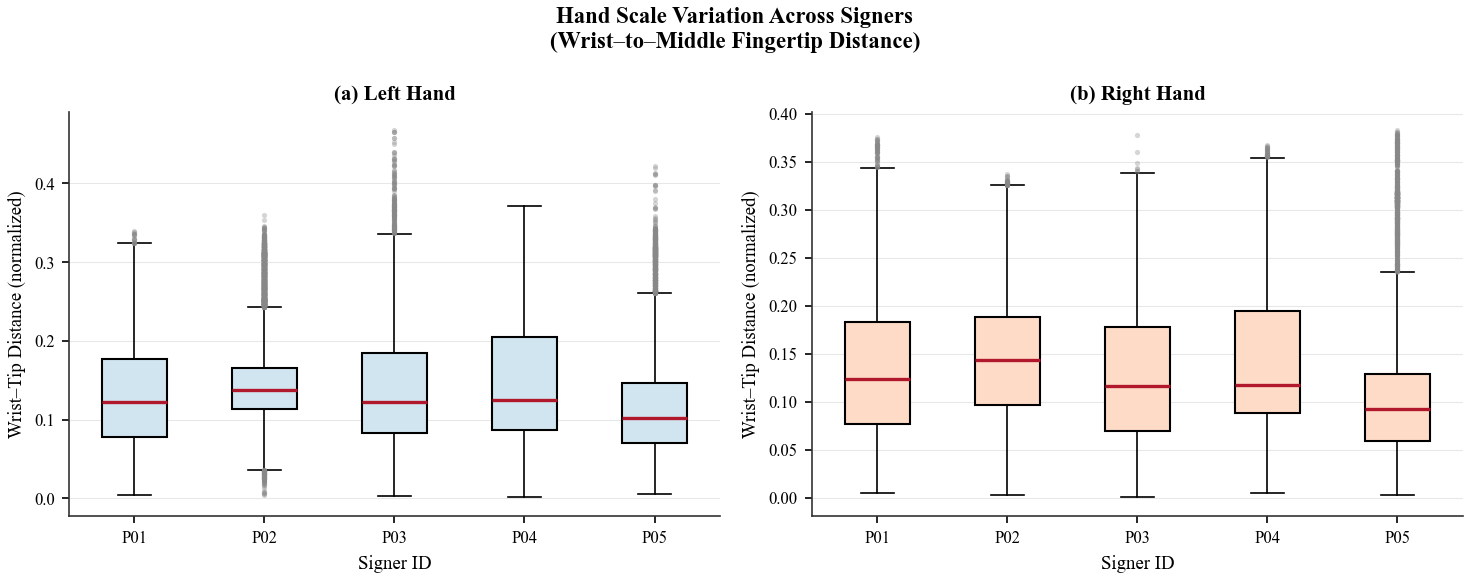

[SAVED] spatial_B_boxplot_scale.png


In [10]:
# ── Fig B: Wrist → Middle Finger Tip Distance Boxplot per Signer ────────────────
# Keypoint: wrist LH=0, middle tip LH=12 | wrist RH=21, middle tip RH=33
# This Euclidean distance represents the relative 'hand size' per signer

WRIST_LH, TIP_LH = 0, 12
WRIST_RH, TIP_RH = 21, 33

sp_dist_lh = defaultdict(list)
sp_dist_rh = defaultdict(list)

for vid in video_ids:
    sp = vid.split('_')[0]
    kp = data[vid]['keypoints']  # (T, K, 2)
    for t in range(kp.shape[0]):
        # Left hand
        w, tip = kp[t, WRIST_LH], kp[t, TIP_LH]
        if not (w[0]==0 and w[1]==0) and not (tip[0]==0 and tip[1]==0):
            sp_dist_lh[sp].append(np.linalg.norm(tip - w))
        # Right hand
        w, tip = kp[t, WRIST_RH], kp[t, TIP_RH]
        if not (w[0]==0 and w[1]==0) and not (tip[0]==0 and tip[1]==0):
            sp_dist_rh[sp].append(np.linalg.norm(tip - w))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.0), dpi=150)
colors_box = ['#D1E5F0', '#FDDBC7']
C_MED = '#B2182B'

for ax, sp_dist, title, fill_c in zip(
    axes,
    [sp_dist_lh, sp_dist_rh],
    ['(a) Left Hand', '(b) Right Hand'],
    colors_box
):
    sp_sorted = sorted(sp_dist.keys())
    bdata = [sp_dist[s] for s in sp_sorted]
    bp = ax.boxplot(
        bdata, labels=sp_sorted, patch_artist=True,
        medianprops=dict(color=C_MED, linewidth=1.6),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        flierprops=dict(marker='o', markersize=2.5,
                        alpha=0.35, markeredgecolor='none',
                        markerfacecolor='#888888')
    )
    for patch in bp['boxes']:
        patch.set_facecolor(fill_c)
    ax.set_title(title)
    ax.set_xlabel('Signer ID')
    ax.set_ylabel('Wrist–Tip Distance (normalized)')
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('Hand Scale Variation Across Signers\n(Wrist–to–Middle Fingertip Distance)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spatial_B_boxplot_scale.png'))
plt.show()
print('[SAVED] spatial_B_boxplot_scale.png')

Candidate videos: ['P01_S023_R01', 'P02_S023_R01', 'P03_S023_R01', 'P04_S023_R01', 'P05_S023_R01']


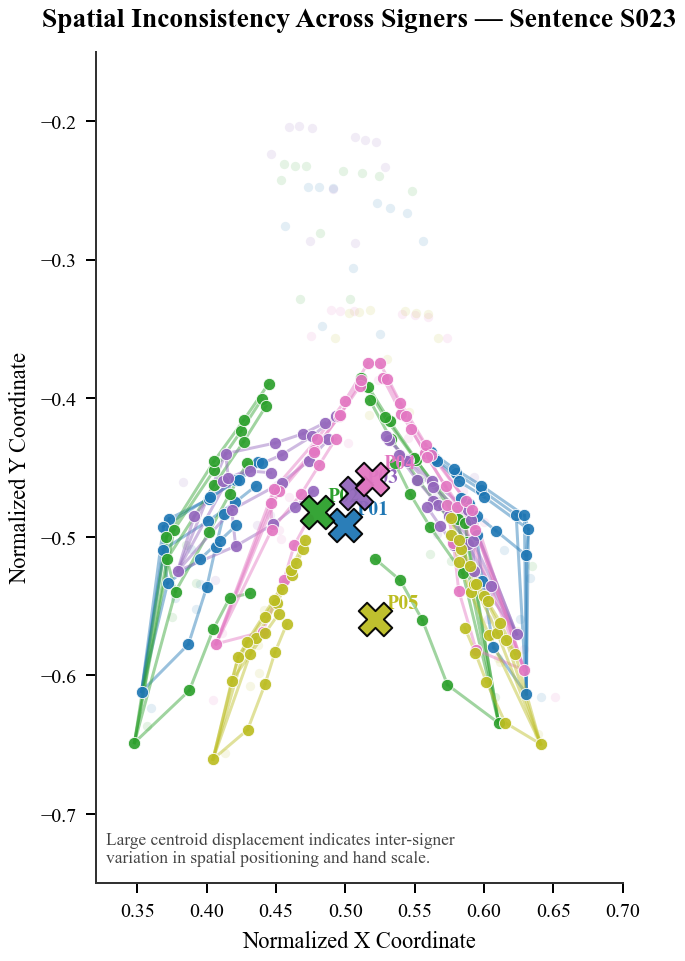

[SAVED] ../data/results\q1_spatial_inconsistency_overlay.png


In [23]:
# ── Fig C: Skeleton Overlay of Several Signers (Same Sentence) ─────────
# Shows variations in position & size visually and intuitively
# Select 1 same sentence ID, take 1 representative frame per signer

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
TARGET_SENTENCE = 'S001'    # Change with a sentence ID that exists in your data
TARGET_REP      = 'R01'
FRAME_IDX       = 10        # Which frame index to take
# ──────────────────────────────────────────────────────────────────────────────

candidate_vids = [
    v for v in video_ids
    if TARGET_SENTENCE in v and TARGET_REP in v
]
candidate_vids = sorted(candidate_vids)
print(f'Candidate videos for {TARGET_SENTENCE}_{TARGET_REP}: {candidate_vids}')

n_sp = len(candidate_vids)
fig, axes = plt.subplots(1, n_sp, figsize=(2.8 * n_sp, 3.5), dpi=150)
if n_sp == 1:
    axes = [axes]

margin = 0.1

for ax, vid in zip(axes, candidate_vids):
    sp_label = vid.split('_')[0]
    kp = data[vid]['keypoints']
    fidx = min(FRAME_IDX, kp.shape[0] - 1)
    frame = kp[fidx].copy()  # (K, 2)
    valid = ~((frame[:,0] == 0) & (frame[:,1] == 0))

    # RAW coordinates — no centering, to show positional variation
    for u, v in CONNECTIONS:
        if valid[u] and valid[v]:
            ax.plot([frame[u,0], frame[v,0]], [-frame[u,1], -frame[v,1]],
                    color=C_EDGE, linewidth=1.0, alpha=0.6, zorder=1)

    idx_lh_v = IDX_LH[valid[IDX_LH]]
    idx_rh_v = IDX_RH[valid[IDX_RH]]
    ax.scatter(frame[idx_lh_v,0], -frame[idx_lh_v,1],
               s=25, color=C_LH, edgecolors='white', linewidths=0.3, zorder=2)
    ax.scatter(frame[idx_rh_v,0], -frame[idx_rh_v,1],
               s=25, color=C_RH, edgecolors='white', linewidths=0.3, zorder=2)

    ax.set_title(f'{sp_label}\nF{fidx}', fontsize=8.5)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-1.05, 0.05)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5); spine.set_color('#aaaaaa')

legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_LH,
           markersize=7, label='Left Hand'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_RH,
           markersize=7, label='Right Hand'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.suptitle(f'Signer Skeleton Overlay — Sentence {TARGET_SENTENCE} (Raw Coordinates)',
             fontsize=11, fontweight='bold')
plt.subplots_adjust(wspace=0.06, bottom=0.15)
plt.savefig(os.path.join(OUTPUT_DIR, 'spatial_C_skeleton_overlay.png'))
plt.show()
print('[SAVED] spatial_C_skeleton_overlay.png')

---
## IV.2.2.2 — Inter-frame Coordinate Instability (Micro-shift)

Two visualizations:
- **Fig D** — X/Y coordinate fluctuation line chart for a single hand keypoint across the sequence
- **Fig E** — Inter-frame displacement histogram per hand keypoint

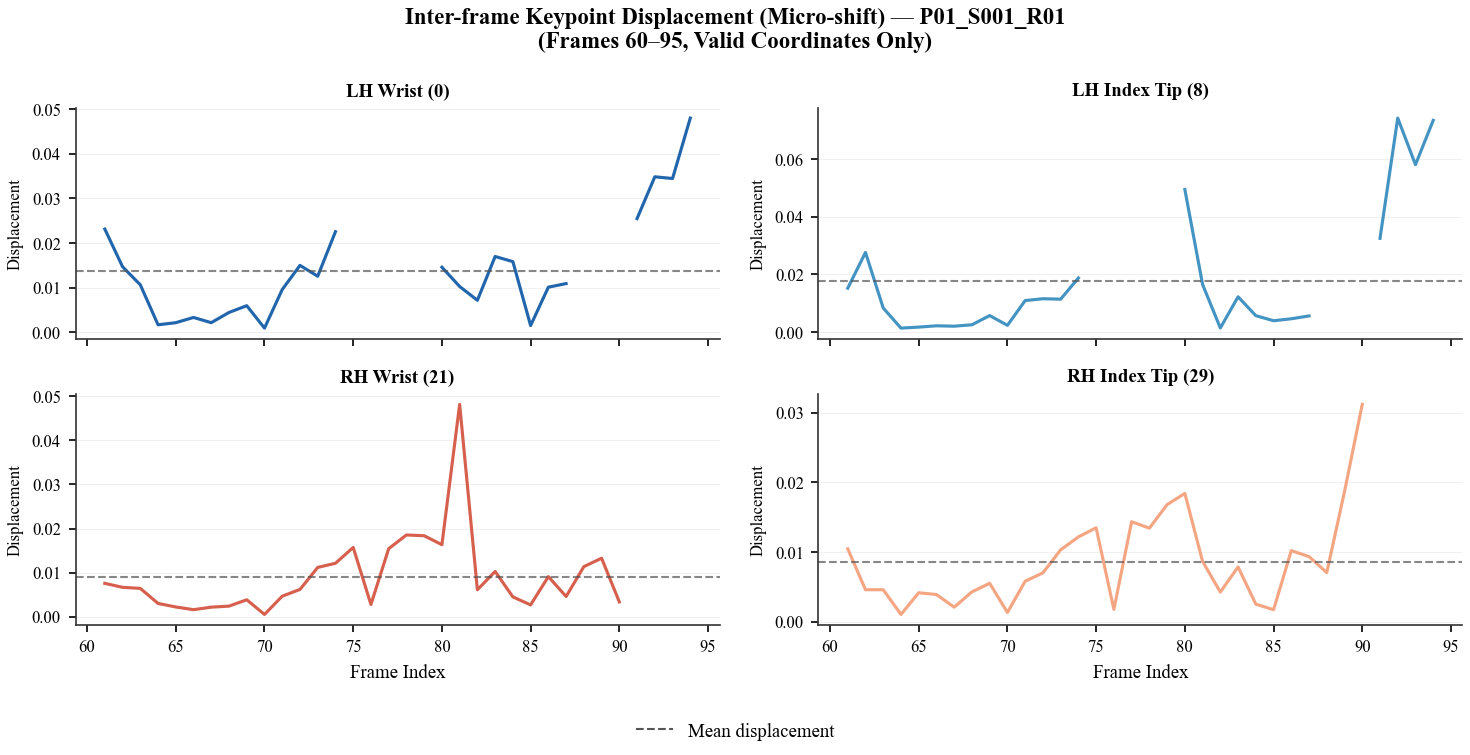

[SAVED] ../data/results\spatial_D_microshift_displacement_curve.png


In [33]:
# ── Fig D: Inter-frame Displacement Curve (Micro-shift Visualization) ─────────
# Purpose:
# Show subtle frame-to-frame coordinate instability (micro-shift)
# using displacement magnitude instead of raw trajectories.

# ── CONFIGURATION ─────────────────────────────────────────────────────────────

TARGET_VIDEO = 'P01_S001_R01'

KEYPOINTS_SHOW = {
    'LH Wrist (0)'      : 0,
    'LH Index Tip (8)'  : 8,
    'RH Wrist (21)'     : 21,
    'RH Index Tip (29)' : 29,
}

FRAME_RANGE = (60, 95)

# ──────────────────────────────────────────────────────────────────────────────

kp = data[TARGET_VIDEO]['keypoints']

fs, fe = FRAME_RANGE

frames_plot = np.arange(
    fs + 1,
    min(fe, kp.shape[0])
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 5),
    dpi=150,
    sharex=True
)

axes = axes.flatten()

line_colors = [
    '#2166AC',
    '#4393C3',
    '#D6604D',
    '#F4A582'
]

# ── PLOT ──────────────────────────────────────────────────────────────────────

for ax, (label, kp_idx), color in zip(
    axes,
    KEYPOINTS_SHOW.items(),
    line_colors
):

    coords = kp[:, kp_idx, :].astype(float)

    disp = []
    valid_frames = []

    for t in range(fs + 1, min(fe, kp.shape[0])):

        prev = coords[t - 1]
        curr = coords[t]

        # Skip missing-noise [0,0]
        prev_invalid = (
            (prev[0] == 0) and
            (prev[1] == 0)
        )

        curr_invalid = (
            (curr[0] == 0) and
            (curr[1] == 0)
        )

        if prev_invalid or curr_invalid:
            disp.append(np.nan)
            valid_frames.append(t)
            continue

        # Inter-frame displacement
        d = np.linalg.norm(curr - prev)

        # Remove extreme tracking jumps
        if d > 0.08:
            disp.append(np.nan)
        else:
            disp.append(d)

        valid_frames.append(t)

    disp = np.array(disp)

    # ── Plot displacement curve ──────────────────────────────────────────────

    ax.plot(
        valid_frames,
        disp,
        color=color,
        linewidth=1.5,
        zorder=2
    )

    # Mean displacement reference
    mean_disp = np.nanmean(disp)

    ax.axhline(
        mean_disp,
        linestyle='--',
        linewidth=1,
        color='#555555',
        alpha=0.7,
        label='Mean displacement'
    )

    # ── Style ────────────────────────────────────────────────────────────────

    ax.set_title(
        label,
        fontsize=9
    )

    ax.set_ylabel(
        'Displacement',
        fontsize=8
    )

    ax.grid(
        axis='y',
        alpha=0.22,
        linewidth=0.4
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# ── X Labels ──────────────────────────────────────────────────────────────────

for ax in axes[2:]:

    ax.set_xlabel(
        'Frame Index'
    )

# ── Shared Legend ─────────────────────────────────────────────────────────────

legend_handles = [

    Line2D(
        [0], [0],
        color='#555555',
        linestyle='--',
        linewidth=1,
        label='Mean displacement'
    )
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=1,
    bbox_to_anchor=(0.5, -0.02),
    frameon=False
)

# ── Title ─────────────────────────────────────────────────────────────────────

plt.suptitle(
    f'Inter-frame Keypoint Displacement (Micro-shift) — {TARGET_VIDEO}\n'
    f'(Frames {fs}–{fe}, Valid Coordinates Only)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

# ── Save ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_D_microshift_displacement_curve.png'
)

plt.savefig(
    save_path,
    dpi=600
)

plt.show()

print(f'[SAVED] {save_path}')

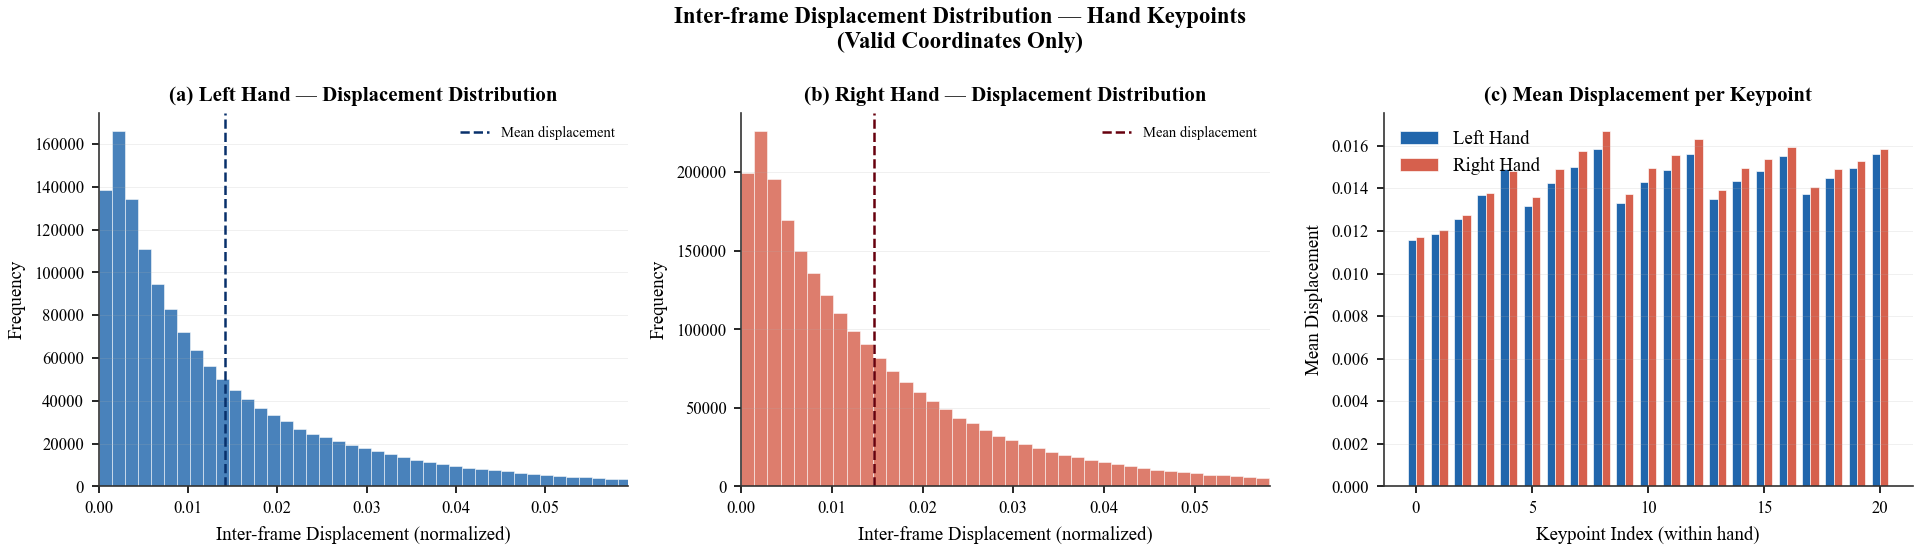

[SAVED] ../data/results\spatial_E_displacement_histogram_clean.png


In [29]:
# ── Fig E: Inter-frame Displacement Distribution (Valid Coordinates Only) ────
# Purpose:
# Quantify subtle inter-frame coordinate fluctuations (micro-shift)
# while excluding missing-noise [0,0] frames.

# ── COMPUTE INTER-FRAME DISPLACEMENT ─────────────────────────────────────────

displacements_lh = defaultdict(list)
displacements_rh = defaultdict(list)

for vid in video_ids:

    kp = data[vid]['keypoints']   # (T, K, 2)

    for kp_idx in range(42):

        coords = kp[:, kp_idx, :]   # (T, 2)

        for t in range(1, coords.shape[0]):

            prev = coords[t - 1]
            curr = coords[t]

            # Exclude missing-noise [0,0]
            prev_invalid = (
                (prev[0] == 0) and
                (prev[1] == 0)
            )

            curr_invalid = (
                (curr[0] == 0) and
                (curr[1] == 0)
            )

            if prev_invalid or curr_invalid:
                continue

            # Euclidean inter-frame displacement
            d = np.linalg.norm(curr - prev)

            # Ignore extreme jumps (likely tracking failure)
            if d > 0.08:
                continue

            if kp_idx < 21:
                displacements_lh[kp_idx].append(d)
            else:
                displacements_rh[kp_idx - 21].append(d)

# ── AGGREGATE ─────────────────────────────────────────────────────────────────

mean_disp_lh = [
    np.mean(displacements_lh[i]) if displacements_lh[i] else 0
    for i in range(21)
]

mean_disp_rh = [
    np.mean(displacements_rh[i]) if displacements_rh[i] else 0
    for i in range(21)
]

all_disp_lh = [
    d
    for kp_dists in displacements_lh.values()
    for d in kp_dists
]

all_disp_rh = [
    d
    for kp_dists in displacements_rh.values()
    for d in kp_dists
]

# ── FIGURE ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 3.8),
    dpi=150
)

# ── (a) Left-hand displacement histogram ─────────────────────────────────────

axes[0].hist(
    all_disp_lh,
    bins=55,
    color='#2166AC',
    alpha=0.82,
    edgecolor='white',
    linewidth=0.3
)

# Mean line
axes[0].axvline(
    np.mean(all_disp_lh),
    color='#08306B',
    linestyle='--',
    linewidth=1.2,
    label='Mean displacement'
)

axes[0].set_title(
    '(a) Left Hand — Displacement Distribution'
)

axes[0].set_xlabel(
    'Inter-frame Displacement (normalized)'
)

axes[0].set_ylabel(
    'Frequency'
)

axes[0].set_xlim(
    0,
    np.percentile(all_disp_lh, 98)
)

axes[0].legend(
    frameon=False,
    fontsize=7
)

# ── (b) Right-hand displacement histogram ────────────────────────────────────

axes[1].hist(
    all_disp_rh,
    bins=55,
    color='#D6604D',
    alpha=0.82,
    edgecolor='white',
    linewidth=0.3
)

axes[1].axvline(
    np.mean(all_disp_rh),
    color='#67000D',
    linestyle='--',
    linewidth=1.2,
    label='Mean displacement'
)

axes[1].set_title(
    '(b) Right Hand — Displacement Distribution'
)

axes[1].set_xlabel(
    'Inter-frame Displacement (normalized)'
)

axes[1].set_ylabel(
    'Frequency'
)

axes[1].set_xlim(
    0,
    np.percentile(all_disp_rh, 98)
)

axes[1].legend(
    frameon=False,
    fontsize=7
)

# ── (c) Mean displacement per keypoint ───────────────────────────────────────

x = np.arange(21)
w = 0.36

axes[2].bar(
    x - w/2,
    mean_disp_lh,
    width=w,
    color='#2166AC',
    edgecolor='white',
    linewidth=0.3,
    label='Left Hand'
)

axes[2].bar(
    x + w/2,
    mean_disp_rh,
    width=w,
    color='#D6604D',
    edgecolor='white',
    linewidth=0.3,
    label='Right Hand'
)

axes[2].set_title(
    '(c) Mean Displacement per Keypoint'
)

axes[2].set_xlabel(
    'Keypoint Index (within hand)'
)

axes[2].set_ylabel(
    'Mean Displacement'
)

axes[2].legend(
    frameon=False
)

# ── STYLE ─────────────────────────────────────────────────────────────────────

for ax in axes:

    ax.grid(
        axis='y',
        alpha=0.22,
        linewidth=0.4
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# ── TITLE ─────────────────────────────────────────────────────────────────────

plt.suptitle(
    'Inter-frame Displacement Distribution — Hand Keypoints\n'
    '(Valid Coordinates Only)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

# ── SAVE ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_E_displacement_histogram_clean.png'
)

plt.savefig(
    save_path,
    dpi=600
)

plt.show()

print(f'[SAVED] {save_path}')

---
## IV.2.2.3 — [0,0] Coordinate Noise

Three visualizations:
- **Fig F** — [0,0] noise frequency heatmap per keypoint (all 86 points)
- **Fig G** — Bar chart of percentage of frames with noise per signer
- **Fig H** — Frame visualization with [0,0] keypoints (marked in red)

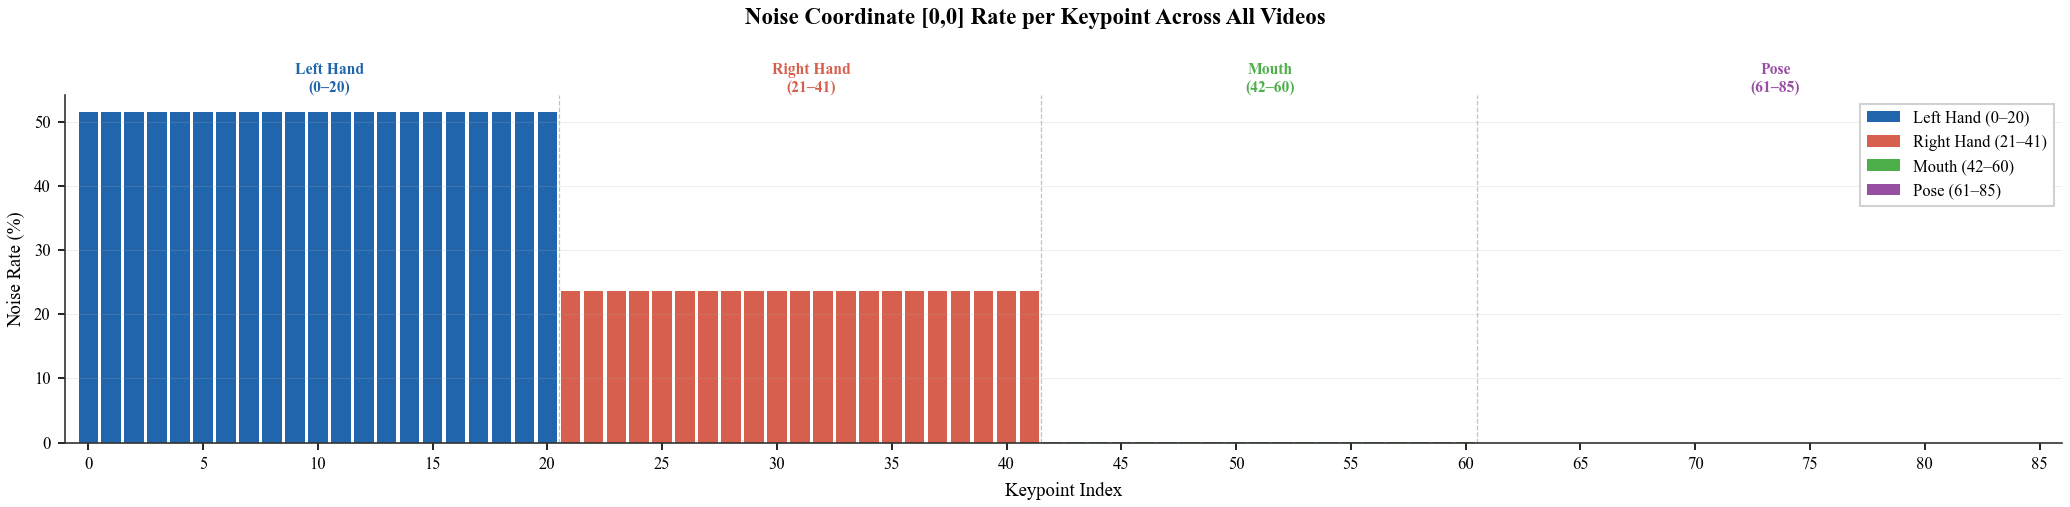

[SAVED] spatial_F_noise_heatmap.png

Top 10 keypoints with highest noise rate:
  Keypoint   0: 51.52%
  Keypoint  10: 51.52%
  Keypoint  19: 51.52%
  Keypoint  18: 51.52%
  Keypoint  17: 51.52%
  Keypoint  16: 51.52%
  Keypoint  15: 51.52%
  Keypoint  14: 51.52%
  Keypoint  13: 51.52%
  Keypoint  12: 51.52%


In [14]:
# ── Fig F: [0,0] Noise Frequency Heatmap per Keypoint ────────────────────────
# Shows which body parts are most frequently undetected by MediaPipe

BODY_PARTS = {
    'Left Hand\n(0–20)'   : (0, 21),
    'Right Hand\n(21–41)' : (21, 42),
    'Mouth\n(42–60)'      : (42, 61),
    'Pose\n(61–85)'       : (61, 86),
}

# Calculate noise frequency per keypoint
noise_count  = np.zeros(K_TOTAL)
total_frames = np.zeros(K_TOTAL)

for vid in video_ids:
    kp = data[vid]['keypoints']  # (T, K, 2)
    T  = kp.shape[0]
    is_noise = (kp[:,:,0] == 0) & (kp[:,:,1] == 0)  # (T, K)
    noise_count  += is_noise.sum(axis=0)
    total_frames += T

noise_rate = noise_count / total_frames  # proportion of frames with noise per keypoint

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5), dpi=150)

x = np.arange(K_TOTAL)
colors_part = ['#2166AC', '#D6604D', '#4DAF4A', '#984EA3']
part_colors = np.empty(K_TOTAL, dtype=object)
for (label, (start, end)), c in zip(BODY_PARTS.items(), colors_part):
    part_colors[start:end] = c

bars = ax.bar(x, noise_rate * 100, width=0.85,
              color=part_colors, edgecolor='none')

# Partition boundaries
for (label, (start, end)), c in zip(BODY_PARTS.items(), colors_part):
    mid = (start + end) / 2
    ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
            label, ha='center', va='bottom', fontsize=7.5,
            color=c, fontweight='bold')
    if end < K_TOTAL:
        ax.axvline(end - 0.5, color='#999999', linewidth=0.6,
                   linestyle='--', alpha=0.6)

ax.set_xlabel('Keypoint Index')
ax.set_ylabel('Noise Rate (%)')
ax.set_xlim(-1, K_TOTAL)
ax.set_xticks(np.arange(0, K_TOTAL, 5))
ax.grid(axis='y', alpha=0.25, linewidth=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend_handles = [Patch(facecolor=c, label=lbl.replace('\n', ' '))
                  for (lbl, _), c in zip(BODY_PARTS.items(), colors_part)]
ax.legend(handles=legend_handles, loc='upper right',
          framealpha=0.9, edgecolor='#cccccc', fancybox=False, fontsize=8)

plt.suptitle('Noise Coordinate [0,0] Rate per Keypoint Across All Videos',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spatial_F_noise_heatmap.png'))
plt.show()

print('[SAVED] spatial_F_noise_heatmap.png')
print(f'\nTop 10 keypoints with highest noise rate:')
top10 = np.argsort(noise_rate)[::-1][:10]
for idx in top10:
    print(f'  Keypoint {idx:3d}: {noise_rate[idx]*100:.2f}%')

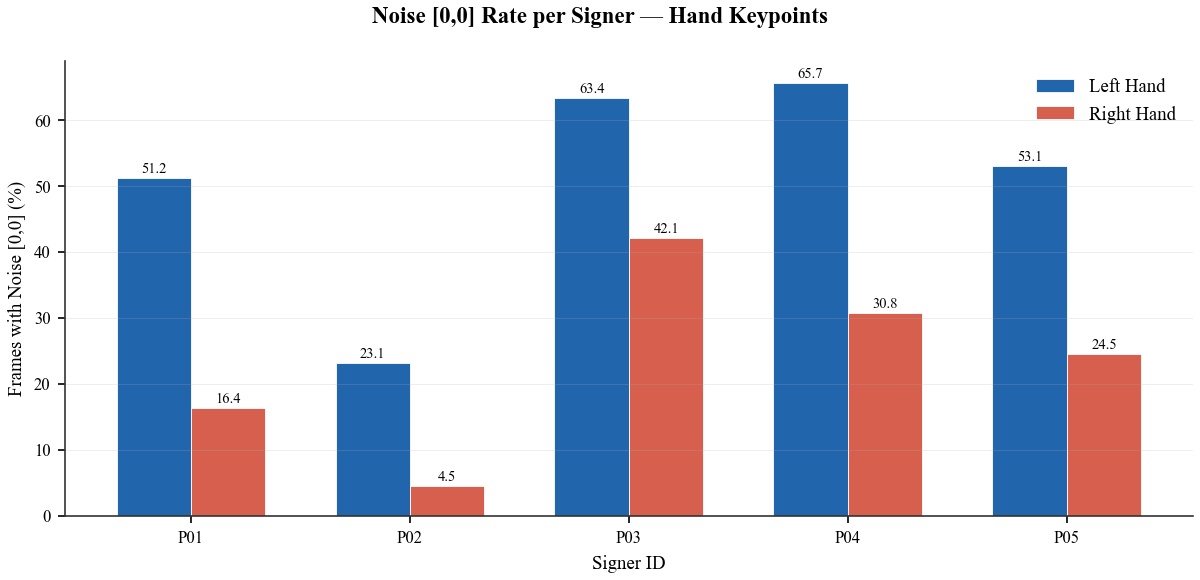

[SAVED] ../data/results\spatial_G_noise_per_signer.png


In [34]:
# ── Fig G: Percentage of Frames with Noise per Signer ─────────────────────────
# Shows variation in MediaPipe detection quality across signers

# ── Compute Noise Rate per Hand ───────────────────────────────────────────────

sp_noise_lh, sp_noise_rh = {}, {}

for sp in speakers:

    sp_vids = [
        v for v in video_ids
        if v.startswith(sp)
    ]

    total_f = 0
    n_lh = 0
    n_rh = 0

    for vid in sp_vids:

        kp = data[vid]['keypoints']
        T  = kp.shape[0]

        # Frame considered noisy if at least one keypoint becomes [0,0]

        noise_lh = (
            (kp[:, :21, 0] == 0) &
            (kp[:, :21, 1] == 0)
        ).any(axis=1)

        noise_rh = (
            (kp[:, 21:42, 0] == 0) &
            (kp[:, 21:42, 1] == 0)
        ).any(axis=1)

        total_f += T
        n_lh += noise_lh.sum()
        n_rh += noise_rh.sum()

    sp_noise_lh[sp] = (
        n_lh / total_f * 100
        if total_f > 0 else 0
    )

    sp_noise_rh[sp] = (
        n_rh / total_f * 100
        if total_f > 0 else 0
    )

# ── Plot ──────────────────────────────────────────────────────────────────────

sp_sorted = sorted(speakers)

x = np.arange(len(sp_sorted))
w = 0.34

fig, ax = plt.subplots(
    figsize=(8.2, 4.0),
    dpi=150
)

# Left Hand
b0 = ax.bar(
    x - w/2,
    [sp_noise_lh[s] for s in sp_sorted],
    width=w,
    color='#2166AC',
    edgecolor='white',
    linewidth=0.4,
    label='Left Hand'
)

# Right Hand
b1 = ax.bar(
    x + w/2,
    [sp_noise_rh[s] for s in sp_sorted],
    width=w,
    color='#D6604D',
    edgecolor='white',
    linewidth=0.4,
    label='Right Hand'
)

# ── Value Labels ──────────────────────────────────────────────────────────────

for bars in [b0, b1]:

    for bar in bars:

        h = bar.get_height()

        if h > 0.5:

            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.4,
                f'{h:.1f}',
                ha='center',
                va='bottom',
                fontsize=7
            )

# ── Style ─────────────────────────────────────────────────────────────────────

ax.set_xticks(x)
ax.set_xticklabels(sp_sorted)

ax.set_xlabel('Signer ID')
ax.set_ylabel('Frames with Noise [0,0] (%)')

ax.legend(frameon=False)

ax.grid(
    axis='y',
    alpha=0.25,
    linewidth=0.4
)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ── Title ─────────────────────────────────────────────────────────────────────

plt.suptitle(
    'Noise [0,0] Rate per Signer — Hand Keypoints',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_G_noise_per_signer.png'
)

plt.savefig(
    save_path,
    dpi=600
)

plt.show()

print(f'[SAVED] {save_path}')

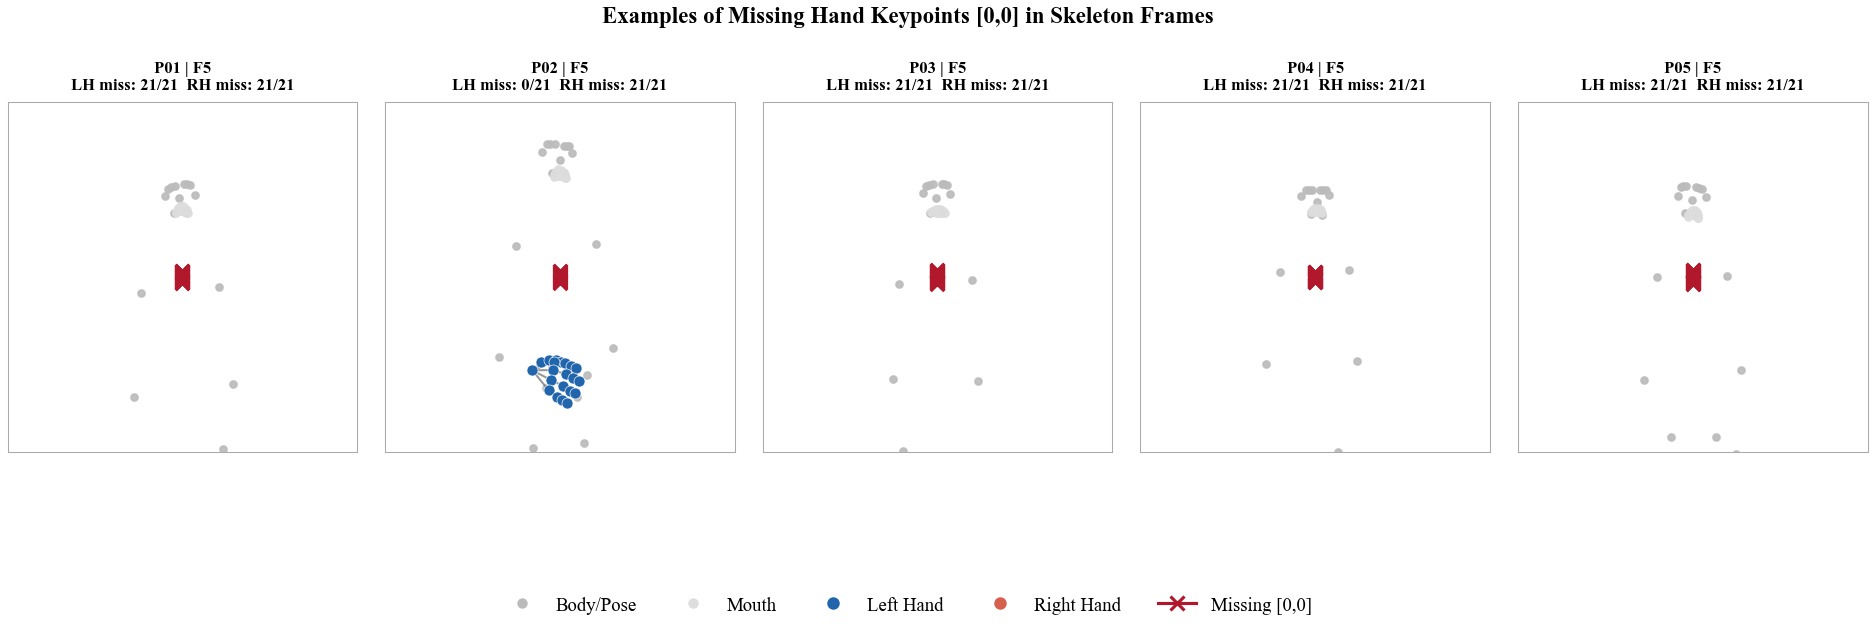

[SAVED] ../data/results\spatial_H_manual_missing_frames.png


In [39]:
# ── Fig H: Manual Examples of Missing Keypoints [0,0] ────────────────────────
# Purpose:
# Visualize selected frames with partial missing hand keypoints
# while preserving body and mouth context.

# ── CONFIGURATION ─────────────────────────────────────────────────────────────

SELECTED_FRAMES = [

    ('P01_S023_R01', 5),
    ('P02_S023_R01', 5),
    ('P03_S023_R01', 5),
    ('P04_S023_R01', 5),
    ('P05_S023_R01', 5),
]

# Index groups
IDX_LH    = np.arange(0, 21)
IDX_RH    = np.arange(21, 42)
IDX_MOUTH = np.arange(42, 61)
IDX_POSE  = np.arange(61, 86)

# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    len(SELECTED_FRAMES),
    figsize=(3.2 * len(SELECTED_FRAMES), 4.0),
    dpi=150
)

if len(SELECTED_FRAMES) == 1:
    axes = [axes]

# ── Plot ──────────────────────────────────────────────────────────────────────

for ax, (vid, fidx) in zip(axes, SELECTED_FRAMES):

    kp = data[vid]['keypoints']

    if fidx >= kp.shape[0]:

        raise ValueError(
            f'Frame {fidx} exceeds sequence length for {vid}'
        )

    frame = kp[fidx].copy()

    is_noise = (
        (frame[:, 0] == 0) &
        (frame[:, 1] == 0)
    )

    valid = ~is_noise

    # ── Center Skeleton ──────────────────────────────────────────────────────

    valid_idx = np.where(valid)[0]

    cx = frame[valid_idx, 0].mean()
    cy = frame[valid_idx, 1].mean()

    f_plot = frame.copy().astype(float)

    f_plot[:, 0] = -(f_plot[:, 0] - cx)
    f_plot[:, 1] = -(f_plot[:, 1] - cy)

    # ── Draw Body / Pose ─────────────────────────────────────────────────────

    pose_valid = IDX_POSE[valid[IDX_POSE]]

    ax.scatter(
        f_plot[pose_valid, 0],
        f_plot[pose_valid, 1],
        s=10,
        color='#BBBBBB',
        alpha=0.9,
        zorder=1
    )

    # ── Draw Mouth ───────────────────────────────────────────────────────────

    mouth_valid = IDX_MOUTH[valid[IDX_MOUTH]]

    ax.scatter(
        f_plot[mouth_valid, 0],
        f_plot[mouth_valid, 1],
        s=10,
        color='#DDDDDD',
        alpha=0.9,
        zorder=1
    )

    # ── Draw Hand Skeleton Connections ──────────────────────────────────────

    for u, v in CONNECTIONS:

        if valid[u] and valid[v]:

            ax.plot(
                [f_plot[u, 0], f_plot[v, 0]],
                [f_plot[u, 1], f_plot[v, 1]],
                color=C_EDGE,
                linewidth=1.0,
                alpha=0.6,
                zorder=2
            )

    # ── Left Hand ────────────────────────────────────────────────────────────

    lh_valid = IDX_LH[valid[IDX_LH]]

    ax.scatter(
        f_plot[lh_valid, 0],
        f_plot[lh_valid, 1],
        s=28,
        color=C_LH,
        edgecolors='white',
        linewidths=0.3,
        zorder=3
    )

    # ── Right Hand ───────────────────────────────────────────────────────────

    rh_valid = IDX_RH[valid[IDX_RH]]

    ax.scatter(
        f_plot[rh_valid, 0],
        f_plot[rh_valid, 1],
        s=28,
        color=C_RH,
        edgecolors='white',
        linewidths=0.3,
        zorder=3
    )

    # ── Missing Hand Keypoints ───────────────────────────────────────────────

    noise_idx = np.where(is_noise[:42])[0]

    if len(noise_idx):

        ax.scatter(
            np.zeros(len(noise_idx)),
            np.linspace(-0.02, 0.02, len(noise_idx)),
            marker='x',
            s=42,
            color=C_NOISE,
            linewidths=1.4,
            zorder=4
        )

    # ── Title ────────────────────────────────────────────────────────────────

    lh_noise = is_noise[:21].sum()
    rh_noise = is_noise[21:42].sum()

    ax.set_title(
        f'{vid.split("_")[0]} | F{fidx}\n'
        f'LH miss: {lh_noise}/21  RH miss: {rh_noise}/21',
        fontsize=8
    )

    # ── Dynamic Limits ───────────────────────────────────────────────────────

    valid_points = f_plot[valid_idx]

    side = max(
        valid_points[:, 0].max() - valid_points[:, 0].min(),
        valid_points[:, 1].max() - valid_points[:, 1].min()
    ) * 1.15

    ax.set_xlim(-side/2, side/2)
    ax.set_ylim(-side/2, side/2)

    ax.set_aspect('equal')

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():

        spine.set_linewidth(0.5)
        spine.set_color('#AAAAAA')

# ── Legend ────────────────────────────────────────────────────────────────────

legend_handles = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#BBBBBB',
        markersize=6,
        label='Body/Pose'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#DDDDDD',
        markersize=6,
        label='Mouth'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=C_LH,
        markersize=7,
        label='Left Hand'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=C_RH,
        markersize=7,
        label='Right Hand'
    ),

    Line2D(
        [0], [0],
        marker='x',
        color=C_NOISE,
        markersize=7,
        markeredgewidth=1.5,
        label='Missing [0,0]'
    )
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.06),
    frameon=False
)

# ── Title ─────────────────────────────────────────────────────────────────────

plt.suptitle(
    'Examples of Missing Hand Keypoints [0,0] in Skeleton Frames',
    fontsize=11,
    fontweight='bold'
)

plt.subplots_adjust(
    wspace=0.08,
    bottom=0.18
)

# ── Save ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_H_manual_missing_frames.png'
)

plt.savefig(
    save_path,
    dpi=600
)

plt.show()

print(f'[SAVED] {save_path}')

---
## Summary — Output Files

In [ ]:
print('='*60)
print('  OUTPUT SUMMARY — IV.2.2 Spatial Characteristic Analysis')
print('='*60)
outputs = [
    ('spatial_A_scatter_overlay.png',      'IV.2.2.1 — Hand coordinate scatter overlay for all signers'),
    ('spatial_B_boxplot_scale.png',        'IV.2.2.1 — Hand scale variation boxplot per signer'),
    ('spatial_C_skeleton_overlay.png',     'IV.2.2.1 — Multi-signer skeleton overlay (raw coordinates)'),
    ('spatial_D_microshift_linechart.png', 'IV.2.2.2 — Inter-frame coordinate fluctuation line chart'),
    ('spatial_E_displacement_histogram.png','IV.2.2.2 — Inter-frame displacement histogram per keypoint'),
    ('spatial_F_noise_heatmap.png',        'IV.2.2.3 — Noise rate bar chart per keypoint (86 points)'),
    ('spatial_G_noise_per_signer.png',     'IV.2.2.3 — Noise rate per signer (LH vs RH vs Any)'),
    ('spatial_H_noise_frames.png',         'IV.2.2.3 — Examples of frames with [0,0] keypoints'),
]
for fname, desc in outputs:
    path = os.path.join(OUTPUT_DIR, fname)
    status = '[OK]' if os.path.exists(path) else '[--]'
    print(f'  {status}  {fname}')
    print(f'         → {desc}')
print('='*60)